1: This code install the google gemini AI library

In [ ]:
!pip install -q google-generativeai Pillow

In [ ]:
import google.generativeai as genai  #Imports google gemini AI library
from google.colab import userdata, files #Allows to uploard images and stores API keys from Gemnini AI
from IPython.display import display  #Display image and output inside the colab
from PIL import Image as PILImage  #Work with upload image files
import time  #avoid gemnini free tier request limits
import os #access to operating system function

genai.configure(api_key=userdata.get('GEMINI_API_KEY'))   #THis connect to Gemnini AI by using API key.
print("Gemini initialized successfully.")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Gemini initialized successfully.


Saving screen_shot_2017-03-08_at_1.16.05_pm.webp to screen_shot_2017-03-08_at_1.16.05_pm.webp
Uploaded: screen_shot_2017-03-08_at_1.16.05_pm.webp
Image size: 1290x751 pixels


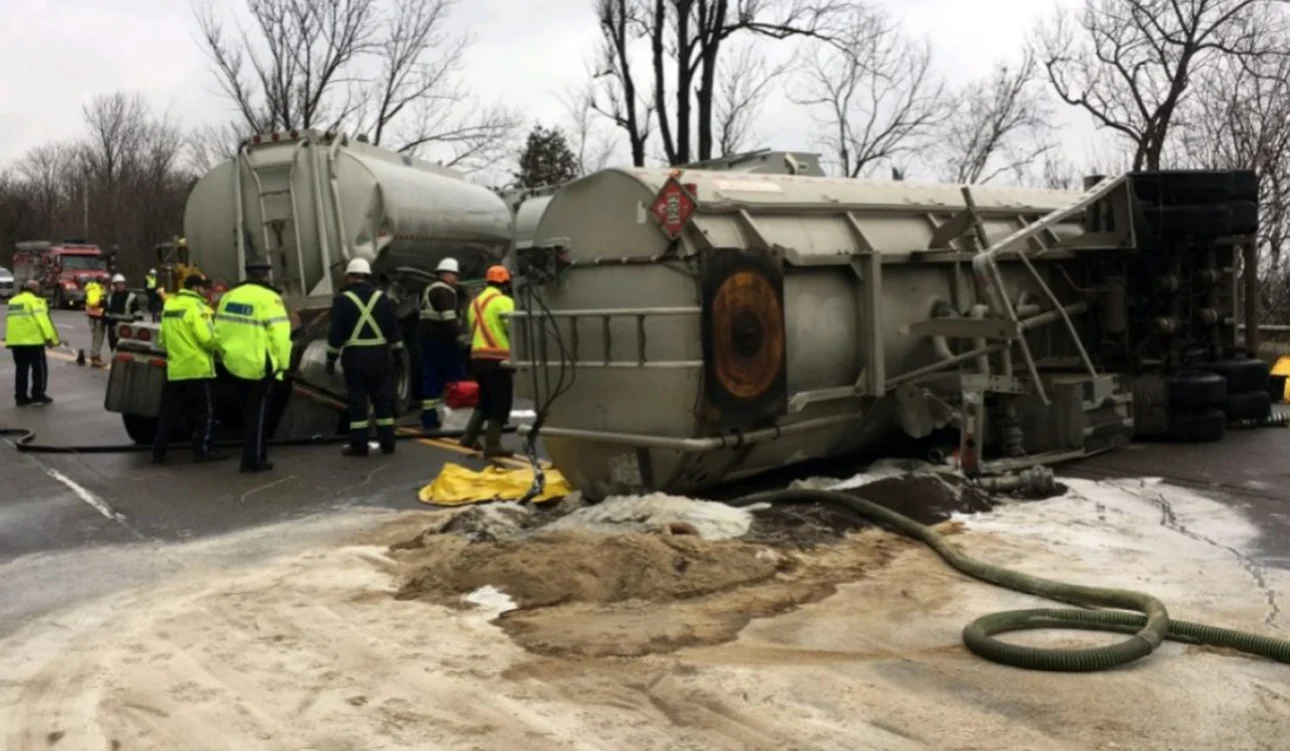

In [ ]:
# Upload your Hazardous waste image from your computer.
uploaded = files.upload()

# Get the filename of the uploaded file.
image_filename = list(uploaded.keys())[0]

# Display the uploaded image so you can see what the model will analyze.
img = PILImage.open(image_filename)
print(f"Uploaded: {image_filename}")
print(f"Image size: {img.size[0]}x{img.size[1]} pixels")
display(img)

In [ ]:
def analyze_image(image_path, question): #This function send both image and question to Gemini AI for analysis
    """
    Send an image + a question to Gemini and return the response.
    Returns: (response_text, usage_metadata)
    """
    m = genai.GenerativeModel(model_name="gemini-2.5-flash") #AI engine powering for hazardous waste detection system
    img = PILImage.open(image_path)
    response = m.generate_content([question, img])   #Send user question and uploaded image to Gemini AI model
    time.sleep(12)  # stays under free tier rate limit
    return response.text, response.usage_metadata  #display to the user

print("analyze_image() function defined. Ready to use in Parts 3 and 4.")

analyze_image() function defined. Ready to use in Parts 3 and 4.


Part 3: Identify what the problem is and explain all the fact about what the hazardous waste is. Which action to take.


In [ ]:
#This create a list of question ask to Gemini AI from the picture that is uploaded
hazardous_questions = [
    ("OBJECT_DETECTION", "Detect and identify hazardous waste items visible in this image."),

    ("HAZARD_CLASSIFICATION", "Determine the type of hazardous material detected and classify its risk category."),

    ("SAFETY_ANALYSIS", "Analyze the potential environmental or workplace dangers associated with the detected waste."),

    ("RECOMMENDED_ACTION", "Recommend the appropriate containment, disposal, or emergency response procedure.")
]

civic_results = {"answers": {}, "total_tokens": 0} #This tracks AI usage free tier limits and Stores each respons from Gemnini

for label, question in hazardous_questions: #This starts a loop that goes through every hazardous waste question one at a time and send it to Gemini AI
    print(f"--- {label} ---")
    answer, usage = analyze_image(image_filename, question) # this send uploaded image and hazardous waste question
    civic_results["answers"][label] = answer #stores the AI response inside the dictionary under matching label
    civic_results["total_tokens"] += usage.total_token_count #add the number of tokens that is use which show how much AI processing was used
    print(answer) #prints AI generation hazardous waste analysis
    print()

print(f"--- Total tokens used: {civic_results['total_tokens']} ---") #dispplay tootal usage for all AI analyses combined
print("Running on Gemini free tier — no cost.") #pprint a message showing that the project is running on google gemini

--- OBJECT_DETECTION ---
Based on the visible evidence in the image:

1.  **Hazardous Waste Item:** The **spilled material on the ground**.

2.  **Identification:** This material is identified as **Diesel Fuel or Light Fuel Oil**.

3.  **Detection and Rationale:**
    *   **Overturned Tanker Truck:** The image clearly shows an overturned tanker truck, indicating a potential spill of its contents.
    *   **Hazardous Material Placard:** On the side of the overturned tanker (visible in the main image and clearer in the second crop), there is a red, diamond-shaped placard with a flame symbol and the number "3" at the bottom point, indicating a **Flammable Liquid (Class 3)**.
    *   Below the flame symbol, the **UN number "1202"** is visible. UN 1202 specifically corresponds to **GAS OIL (diesel fuel) or FUEL OIL, LIGHT**.
    *   **Visible Spill:** A significant amount of light-colored, somewhat liquid or slurry material is spread across the road and shoulder, consistent with a fuel spil

Part 4: Ask question about the hazardous waste

In [ ]:
user_question = input("\nAsk a hazardous waste question about the image: ") #display the question for user to ask question about the image

ai_response, usage = analyze_image(image_filename, user_question) #this send uploaded image the the user question.

print("\n--- AI Hazard Analysis ---")   #Display header for AI response
print(ai_response) #display Image and user question from the Gemini AI

print(f"\nTokens used: {usage.total_token_count}") #This display total number of token use during AI which monitor gemini free tier limits


Ask a hazardous waste question about the image: what type of waste is this

--- AI Hazard Analysis ---
Based on the hazard placard visible on the overturned tanker truck (specifically, in the second cropped image), we can identify the type of waste.

1.  **Hazard Placard:** The placard is a red diamond with a flame symbol, indicating a **Flammable Liquid** (Class 3).
2.  **UN/NA Number:** Below the flame, a four-digit number is visible: **1201**.
3.  **Identification of UN 1201:** UN/NA 1201 corresponds to **Motor Spirit, including gasoline or petrol**.

While the spilled material on the ground appears to be a whitish/light brown, somewhat granular substance (likely sand or other absorbent material applied during cleanup), the original product being transported and spilled is **gasoline (petrol)**. The waste being managed is therefore **gasoline contaminated soil and/or absorbent material**.

Tokens used: 1093
